# Neural Network From Scratch

### Introduction

In this assignment, you're given to task to build your own neural network. You're not allowed to use any libraries that facilitate building a network though! You're going to build it from scratch... with just raw mathematics and Numpy! Don't worry, most of the code will have been written for you. In the end, you will be tasked to train this neural network and get the highest accuracy score on the MNIST Dataset.

### The Assignment

In [145]:
#Import the necessary libraries
import numpy as np
from matplotlib import pyplot as plt

In [146]:
#Here are some activation functions you can use in your neural network

# RELU Activation function.
def relu(x):
    return np.maximum(0.0, x)


# Sigmoid activation function.
def sig(x):
    return 1 / (1 + np.exp(-x))


# Softmax activation function.
def softmax(x):
    return np.exp(x) / np.exp(x).sum()


# Derivative of softmax.
def relu_derivative(x):
    return np.where(x > 0, 1, 0)


# Derivative of sigmoid.
def sigmoid_derivative(x):
    sigmoid_x = 1 / (1 + np.exp(-x))
    return sigmoid_x * (1 - sigmoid_x)


In [147]:
""" 
This class defines the neural network. This network will have one hidden layer. It has the following methods:
# __init__ - Initialises the neural network.
# backpropagation - Backpropogates through the network to update weights and biases.
# predict - Predicts the input.
# train - Trains the neural network.
# The neural network has the following attributes:
# iNodes - The input nodes.
# hNodes - The hidden nodes.
# oNodes - The output nodes.
# wih - The weights for the input and hidden layers.
# who - The weights for the hidden and output layers.
# lr - The learning rate.
# activation_function - The activation function.
"""

class NeuralNetwork:

    # Initialise the neural network.
    def __init__(self, iNodes, hNodes, oNodes, learningRate):
        # Set the nodes in each layer.
        self.iNodes = iNodes
        self.hNodes = hNodes
        self.oNodes = oNodes

        # The weights for the input and hidden layers.
        self.wih = (np.random.rand(self.hNodes, self.iNodes) - 0.5)

        # The weights for the hidden and output layers. 
        self.who = (np.random.rand(self.oNodes, self.hNodes) - 0.5)

        # The Learning rate
        self.lr = learningRate

        # The activation function. Right now it is set to sigmoid.
        self.activation_function = lambda x: sig(x)
        pass

    # Function for backpropogation through the network to update weights and biases.
    def backpropagation(self, inputs, targets, fOutputs, hOutputs):
        """This method backpropogates through the network to update weights and biases.
            It updated the layer for the hidden output and the input hidden."""
        # Backpropogation
        # Getting the output layer error -> (target - actual)
        oErrors = targets - fOutputs

        # Getting the error of the hidden layers.
        hErrors = np.dot(self.who.T, oErrors)

        # Updating the weights for hidden and output layers.
        self.who += self.lr * np.dot((oErrors * fOutputs * (1.0 - fOutputs)), np.transpose(hOutputs))

        # Updating the weights for input and hidden layers.
        self.wih += self.lr * np.dot((hErrors * hOutputs * (1.0 - hOutputs)), np.transpose(inputs))

    # Function for predicting the input.
    def predict(self, iList):
        """This method predicts the input.
            It takes an input and returns an output which is calculated by the activation function. """
        # List converting to 2d array.
        inputs = np.atleast_2d(np.asarray(iList, dtype=float)).T

        hinputs = np.dot(self.wih, inputs)
        houtputs = self.activation_function(hinputs)

        finputs = np.dot(self.who, houtputs)
        return self.activation_function(finputs)

    # Function for training the neural network.
    def train(self, iList, tar_List):
        """This method trains the neural network. It receives an input list and a target list.
            With these given lists the nn is being trained. Backpropagation is used in this method."""
        # List converting to 2d array.
        inputs = np.atleast_2d(np.asarray(iList, dtype=float)).T
        targets = np.atleast_2d(np.asarray(tar_List, dtype=float)).T

        # calculate signals into hidden layer.
        hInputs = np.dot(self.wih, inputs)

        # calculate the signals emerging from hidden layer.
        hOutputs = self.activation_function(hInputs)

        # calculate signals into final output layer
        fInputs = np.dot(self.who, hOutputs)

        fOutputs = self.activation_function(fInputs)

        # Apply backpropagation.
        self.backpropagation(inputs=inputs, targets=targets, fOutputs=fOutputs, hOutputs=hOutputs)

In [148]:
def train_nn(data, epochs):
    """This method trains the neural network. It can take a while.
        It init's the inputs at 0.01 and the targets at 0.99"""
    print("Training can take a while... sit back and relax :)")
    for i in range(epochs):
        print(f'Epoch: {i + 1}')
        for record in data[1:]:
            # split the line by the ',' commas
            values = record.split(',')

            # normalize the data.
            inputs = (np.asarray(values[1:], dtype=float) / 255.0 * 0.99) + 0.01

            # create the target output values, array of output_nodes.
            targets = np.zeros(onodes) + 0.01

            # values[0] is the target label for this record
            targets[int(values[0])] = 0.99

            # Train the network
            nn.train(inputs, targets)

        # Calculate the accuracy of the training.
        accuracy = calculate_train_accuracy(nn, data)
        print(f'Training accuracy at epoch {i + 1}: {accuracy * 100:.2f}%')

In [149]:
def test_nn(data):
    """This method tests the neural network. It loops through all the records in the test data set.
        While looping, it predicts the result of the input. """
    # go through all the records in the test data set
    for record in data[1:]:
        # split the record by the ',' commas
        values = record.split(',')

        # correct answer is first value
        y_true = int(values[0])

        # Normalize the data
        inputs = (np.asarray(values[1:], dtype=float) / 255.0 * 0.99) + 0.01

        # Test the network by predicting
        outputs = nn.predict(inputs)

        # the index of the highest value corresponds to the label
        y_pred = np.argmax(outputs)

        # append correct or incorrect to list to calculate accuracy
        if y_pred == y_true:
            # if guess = correct +1
            score_progress.append(1)
        else:
            # if guess is not correct +0
            score_progress.append(0)
            # Save the incorrect guess data, so it can be plotted later.
            incorrect_guesses.append({
                "correct_label": y_true,
                "guessed_label": y_pred,
                "values": record
            })
        pass


In [150]:
def calculate_train_accuracy(nn, data):
    correct = 0
    total = 0
    for record in data[1:]:
        values = record.split(',')
        inputs = (np.asarray(values[1:], dtype=float) / 255.0 * 0.99) + 0.01
        targets = int(values[0])
        outputs = nn.predict(inputs)
        predicted_label = np.argmax(outputs)
        if predicted_label == targets:
            correct += 1
        total += 1
    return correct / total

In [160]:
def calc_test_accuracy():
    """This method calculates the accuracy of the model on the test set."""
    scorecard_array = np.asarray(score_progress, dtype=int)
    print("performance = ", scorecard_array.sum() / scorecard_array.size)

In [152]:
def get_test_data():
    """This method gets the test_data from the mnist_test file."""
    test_data_file = open("mnist_data/mnist_test.csv", 'r')
    test_data_list = test_data_file.readlines()
    test_data_file.close()
    return test_data_list

In [153]:
def get_train_data():
    """This method gets the train_data from the mnist_train file."""
    train_data_file = open("mnist_data/mnist_train.csv", 'r')
    train_data_list = train_data_file.readlines()
    train_data_file.close()
    return train_data_list

In [159]:
def check_incorrect_guesses(nrows, ncols):
    """This method checks the incorrect guesses and plots them. You can define how many you want to see.
    The amount that will be shown is nrows * ncols"""

    # Init figure.
    fig = plt.figure(figsize=(15, 15))

    # Loop through the amount of images wanted to be seen.
    for i in range(nrows * ncols):
        # Retrieve the data needed.
        correct_label = incorrect_guesses[i]['correct_label']
        guessed_label = incorrect_guesses[i]['guessed_label']
        values = incorrect_guesses[i]['values'].split(',')
        # Convert to array so it can be plotted.
        img_array = np.asarray(values[1:], dtype=float).reshape((28, 28))

        # Add the number plot on correct place.
        fig.add_subplot(nrows, ncols, i + 1)
        plt.imshow(img_array, cmap='Greys',
                   interpolation='None')
        plt.title(f'Number {str(correct_label)} seen as {str(guessed_label)}')
    fig.show()

In [155]:
# Init parameters for network.
inodes, hnodes, onodes, learning_rate = 784, 200, 10, 0.1

# init network
nn = NeuralNetwork(iNodes=inodes, hNodes=hnodes, oNodes=onodes, learningRate=learning_rate)

# Arrays to keep track of the score of the network and the incorrect guesses.
score_progress = []
incorrect_guesses = []

In [156]:
# Train the network with x amount of epochs.
train_nn(data=get_train_data(), epochs=5)

Training can take a while... sit back and relax :)
Epoch: 1
Training accuracy at epoch 1: 96.05%
Epoch: 2
Training accuracy at epoch 2: 97.43%
Epoch: 3
Training accuracy at epoch 3: 97.97%
Epoch: 4
Training accuracy at epoch 4: 98.15%
Epoch: 5
Training accuracy at epoch 5: 98.43%


In [157]:
# Test the network
test_nn(data=get_test_data())

In [161]:
# Calculate the performance.
calc_test_accuracy()

performance =  0.9732


/var/folders/ql/ljj6ml2j5lddpwjnkf1hbs5m0000gn/T/ipykernel_22044/3460609093.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


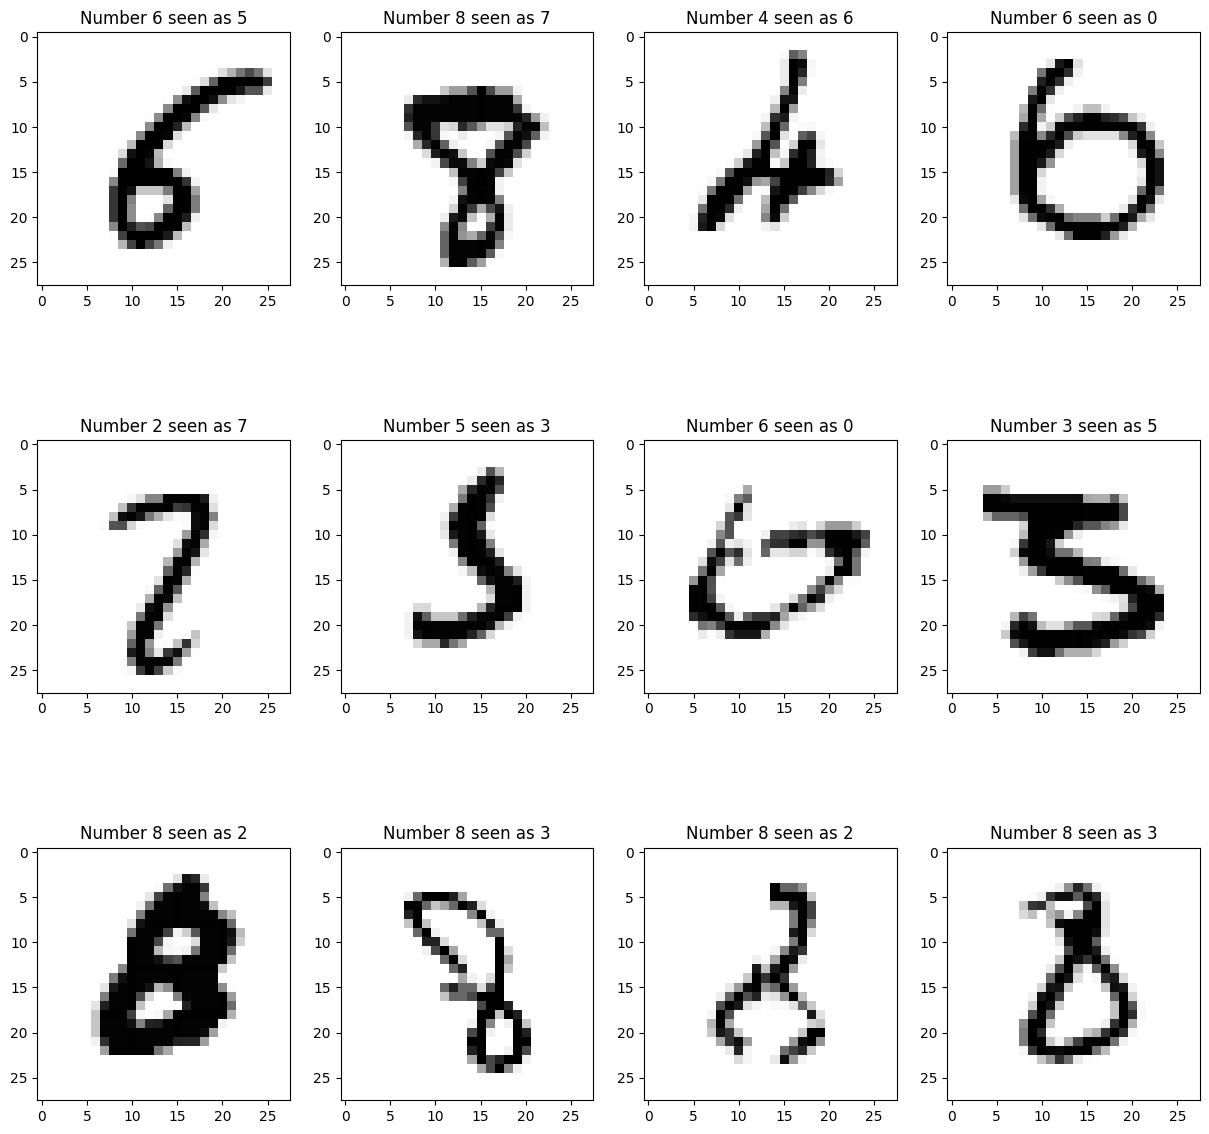

In [162]:
# Plot the incorrect guesses. Amount of plots will be nrows * ncols.
check_incorrect_guesses(nrows=3, ncols=4)

Now that you've trained and tested your network, try to get the best results by tweaking the parameters!

For an extra challenge: Not only try to tweak the parameters, but try to change the structure of the network itself to improve results. (for example add another hidden layer or change the activation function)